<a href="https://colab.research.google.com/github/SKTan03/ShuKaiTan-Portfolio/blob/main/Employee_Attrition_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition — Exploratory Data Analysis
### *Uncovering the drivers of employee turnover through data*

---

> **Dataset:** IBM HR Analytics — Attrition Training Set  
> **Rows:** 3,147 employees · **Features:** 34 columns  
> **Target:** `Attrition` (0 = Stayed, 1 = Left)

---


In [21]:
# Imports & Global Style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# Palette & Theme
STAY   = "#4C9BE8"   # cool blue  → stayed
LEAVE  = "#E8614C"   # warm red   → left
BG     = "#F7F9FC"
DARK   = "#1A1F2E"
ACCENT = "#F0A500"
MID    = "#A8B4C8"

PALETTE = [STAY, LEAVE, ACCENT, "#6ECB8A", "#B36EE8", "#E8C84C"]

custom_cmap = LinearSegmentedColormap.from_list("attrition", [STAY, "#FFFFFF", LEAVE])

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    MID,
    "axes.labelcolor":   DARK,
    "axes.titlecolor":   DARK,
    "axes.titlesize":    14,
    "axes.labelsize":    11,
    "axes.titleweight":  "bold",
    "xtick.color":       DARK,
    "ytick.color":       DARK,
    "text.color":        DARK,
    "grid.color":        "#DDE3ED",
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "legend.framealpha": 0.9,
    "legend.edgecolor":  MID,
})

In [22]:
# Load Dataset
df = pd.read_csv("attrition train.csv", index_col=0)

# Drop constant / ID columns
df.drop(columns=["id", "EmployeeCount", "Over18", "StandardHours"], inplace=True)

# Readable label
df["Attrition_Label"] = df["Attrition"].map({0: "Stayed", 1: "Left"})

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Shape: 3,147 rows × 32 columns


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Attrition_Label
0,36,Travel_Frequently,599,Research & Development,24,3,Medical,4,Male,42,...,1,10,2,3,10,0,7,8,0,Stayed
1,35,Travel_Rarely,921,Sales,8,3,Other,1,Male,46,...,1,4,3,3,4,2,0,3,0,Stayed
2,32,Travel_Rarely,718,Sales,26,3,Marketing,3,Male,80,...,2,4,3,3,3,2,1,2,0,Stayed


In [23]:
# Data Overview
summary = pd.DataFrame({
    "dtype":    df.dtypes,
    "nulls":    df.isnull().sum(),
    "null_%":   (df.isnull().mean() * 100).round(2),
    "unique":   df.nunique(),
    "sample":   [df[c].dropna().iloc[0] if len(df[c].dropna()) else None for c in df.columns],
})
summary


,dtype,nulls,null_%,unique,sample
Age,int64,0,0.0,43,36
BusinessTravel,object,0,0.0,3,Travel_Frequently
DailyRate,int64,0,0.0,901,599
Department,object,0,0.0,3,Research & Development
DistanceFromHome,int64,0,0.0,29,24
Education,int64,0,0.0,6,3
EducationField,object,0,0.0,6,Medical
EnvironmentSatisfaction,int64,0,0.0,4,4
Gender,object,0,0.0,2,Male
HourlyRate,int64,0,0.0,71,42


In [24]:
# Missing Values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values detected — the dataset is complete.")
else:
    print(missing[missing > 0])


No missing values detected — the dataset is complete.


---
##Target Distribution — How Many Employees Left?


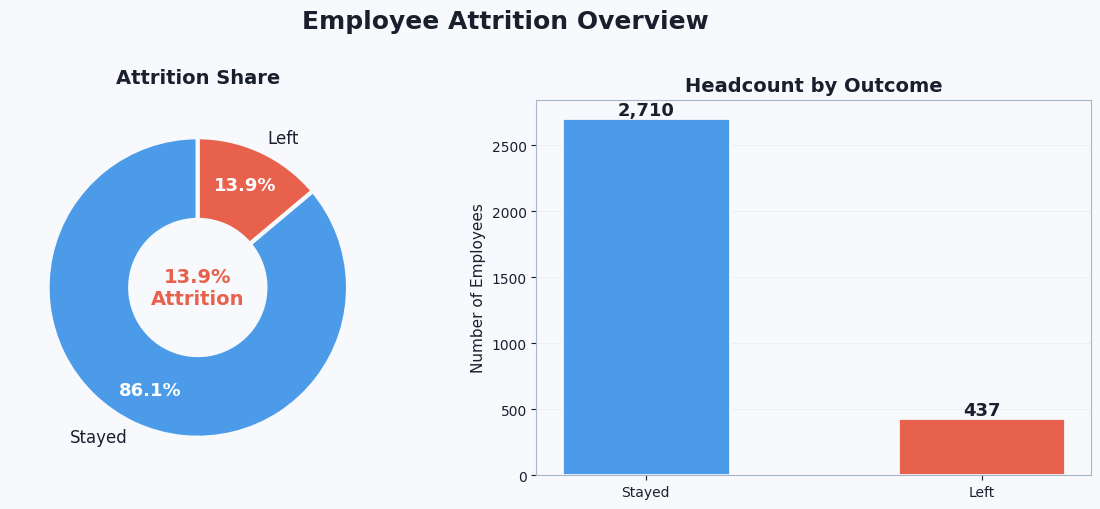


 Attrition rate: 13.9%  |  Stayed: 2,710  |  Left: 437


In [25]:
counts = df["Attrition_Label"].value_counts()
rate   = df["Attrition"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
fig.suptitle("Employee Attrition Overview", fontsize=18, fontweight="bold",
             color=DARK, y=1.01)

# Donut
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct="%1.1f%%",
    colors=[STAY, LEAVE], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3),
    textprops=dict(fontsize=12, color=DARK),
    pctdistance=0.75,
)
for at in autotexts:
    at.set(fontsize=13, fontweight="bold", color="white")
ax.text(0, 0, f"{rate:.1f}%\nAttrition", ha="center", va="center",
        fontsize=14, fontweight="bold", color=LEAVE)
ax.set_title("Attrition Share", pad=12)

# -- Bar --
ax2 = axes[1]
bars = ax2.bar(counts.index, counts.values, color=[STAY, LEAVE],
               width=0.5, edgecolor=BG, linewidth=2)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val:,}", ha="center", fontsize=13, fontweight="bold")
ax2.set_title("Headcount by Outcome")
ax2.set_ylabel("Number of Employees")
ax2.yaxis.grid(True, alpha=0.5)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig_attrition_overview.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\n Attrition rate: {rate:.1f}%  |  Stayed: {counts['Stayed']:,}  |  Left: {counts['Left']:,}")


---
##Age & Income Distributions


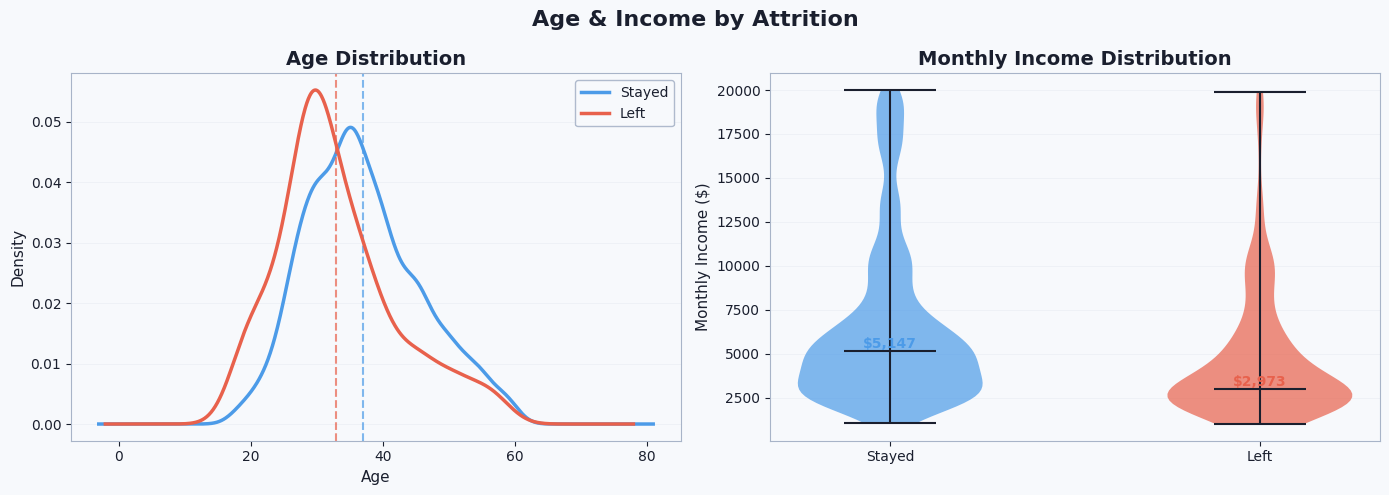

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Age & Income by Attrition", fontsize=16, fontweight="bold", color=DARK)

stayed = df[df["Attrition"] == 0]
left   = df[df["Attrition"] == 1]

# Age KDE
for grp, color, label in [(stayed, STAY, "Stayed"), (left, LEAVE, "Left")]:
    grp["Age"].plot.kde(ax=axes[0], color=color, linewidth=2.5, label=label)
    axes[0].axvline(grp["Age"].mean(), color=color, linestyle="--", linewidth=1.5, alpha=0.7)

axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()
axes[0].yaxis.grid(True, alpha=0.4)
axes[0].set_axisbelow(True)

# Monthly Income violin
parts = axes[1].violinplot(
    [stayed["MonthlyIncome"], left["MonthlyIncome"]],
    positions=[1, 2], showmedians=True, showextrema=True
)
for i, (body, color) in enumerate(zip(parts["bodies"], [STAY, LEAVE])):
    body.set_facecolor(color)
    body.set_alpha(0.7)
parts["cmedians"].set_color(DARK)
parts["cbars"].set_color(DARK)
parts["cmins"].set_color(DARK)
parts["cmaxes"].set_color(DARK)

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Stayed", "Left"])
axes[1].set_title("Monthly Income Distribution")
axes[1].set_ylabel("Monthly Income ($)")
axes[1].yaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)

# Annotate medians
for pos, grp, color in [(1, stayed, STAY), (2, left, LEAVE)]:
    med = grp["MonthlyIncome"].median()
    axes[1].text(pos, med + 200, f"${med:,.0f}", ha="center",
                 fontsize=10, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("fig_age_income.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


---
## Satisfaction & Work-Life Factors


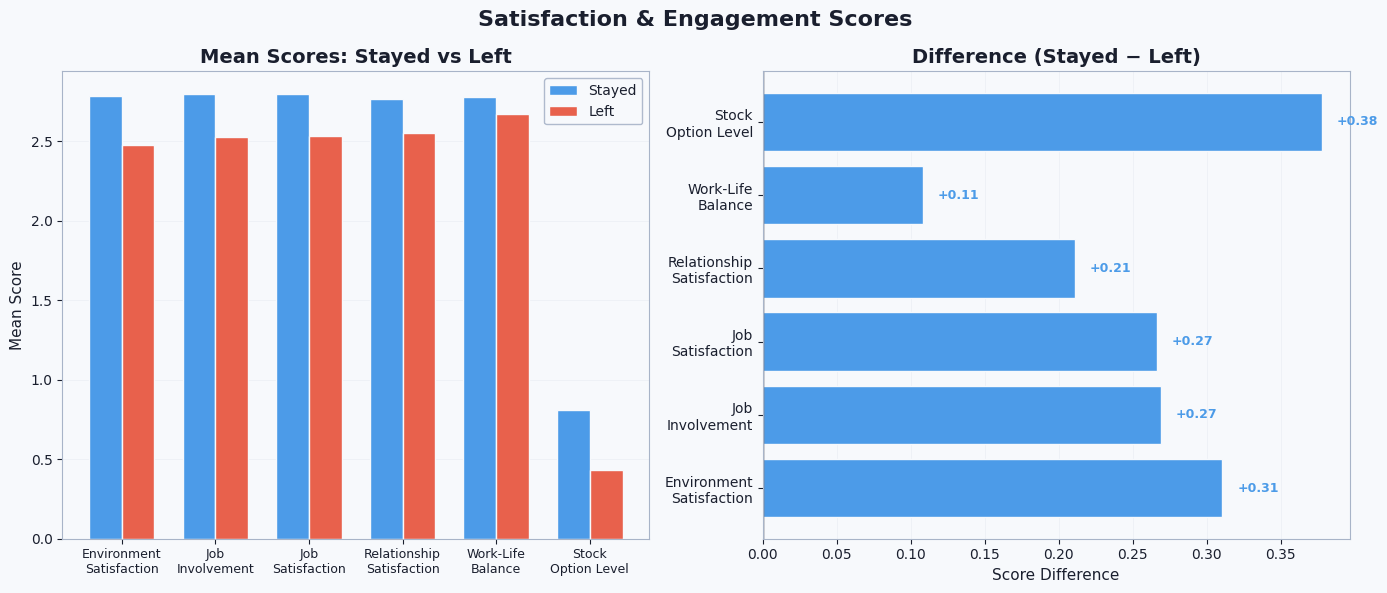

In [27]:
sat_cols = ["EnvironmentSatisfaction", "JobInvolvement",
            "JobSatisfaction", "RelationshipSatisfaction",
            "WorkLifeBalance", "StockOptionLevel"]

label_map = {
    "EnvironmentSatisfaction": "Environment\nSatisfaction",
    "JobInvolvement":          "Job\nInvolvement",
    "JobSatisfaction":         "Job\nSatisfaction",
    "RelationshipSatisfaction":"Relationship\nSatisfaction",
    "WorkLifeBalance":         "Work-Life\nBalance",
    "StockOptionLevel":        "Stock\nOption Level",
}

# Mean score by attrition group
grp_means = df.groupby("Attrition_Label")[sat_cols].mean().T
grp_means.index = [label_map[c] for c in grp_means.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle("Satisfaction & Engagement Scores", fontsize=16, fontweight="bold", color=DARK)

# Grouped bars
x = np.arange(len(sat_cols))
w = 0.35
axes[0].bar(x - w/2, grp_means["Stayed"], w, color=STAY, label="Stayed", edgecolor=BG)
axes[0].bar(x + w/2, grp_means["Left"],   w, color=LEAVE, label="Left",   edgecolor=BG)
axes[0].set_xticks(x)
axes[0].set_xticklabels(grp_means.index, fontsize=9)
axes[0].set_ylabel("Mean Score")
axes[0].set_title("Mean Scores: Stayed vs Left")
axes[0].yaxis.grid(True, alpha=0.4)
axes[0].set_axisbelow(True)
axes[0].legend()

# Difference bar
diff = grp_means["Stayed"] - grp_means["Left"]
colors_diff = [STAY if v > 0 else LEAVE for v in diff]
axes[1].barh(grp_means.index, diff, color=colors_diff, edgecolor=BG)
axes[1].axvline(0, color=DARK, linewidth=1)
axes[1].set_title("Difference (Stayed − Left)")
axes[1].set_xlabel("Score Difference")
axes[1].xaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)

for i, (val, col) in enumerate(zip(diff, colors_diff)):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f"{val:+.2f}", va="center",
                 ha="left" if val >= 0 else "right",
                 fontsize=9, fontweight="bold", color=col)

plt.tight_layout()
plt.savefig("fig_satisfaction.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


---
##Correlation Heatmap (Numeric Features)


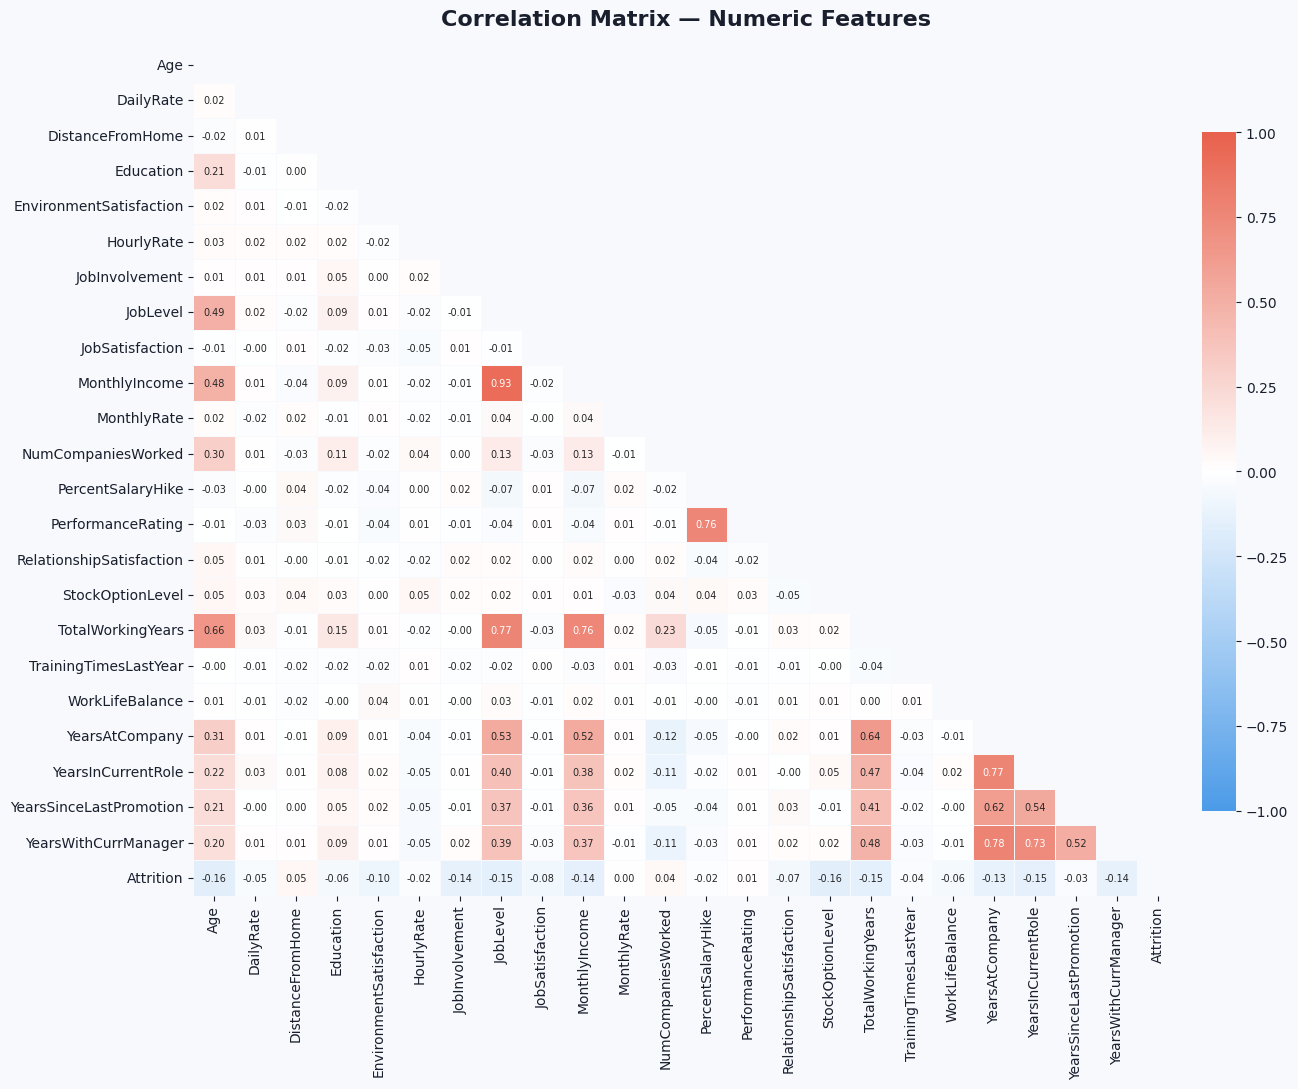

In [28]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11), facecolor=BG)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, ax=ax, cmap=custom_cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, linecolor=BG,
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=16,
             fontweight="bold", pad=16)
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


---
## Tenure & Career Trajectory


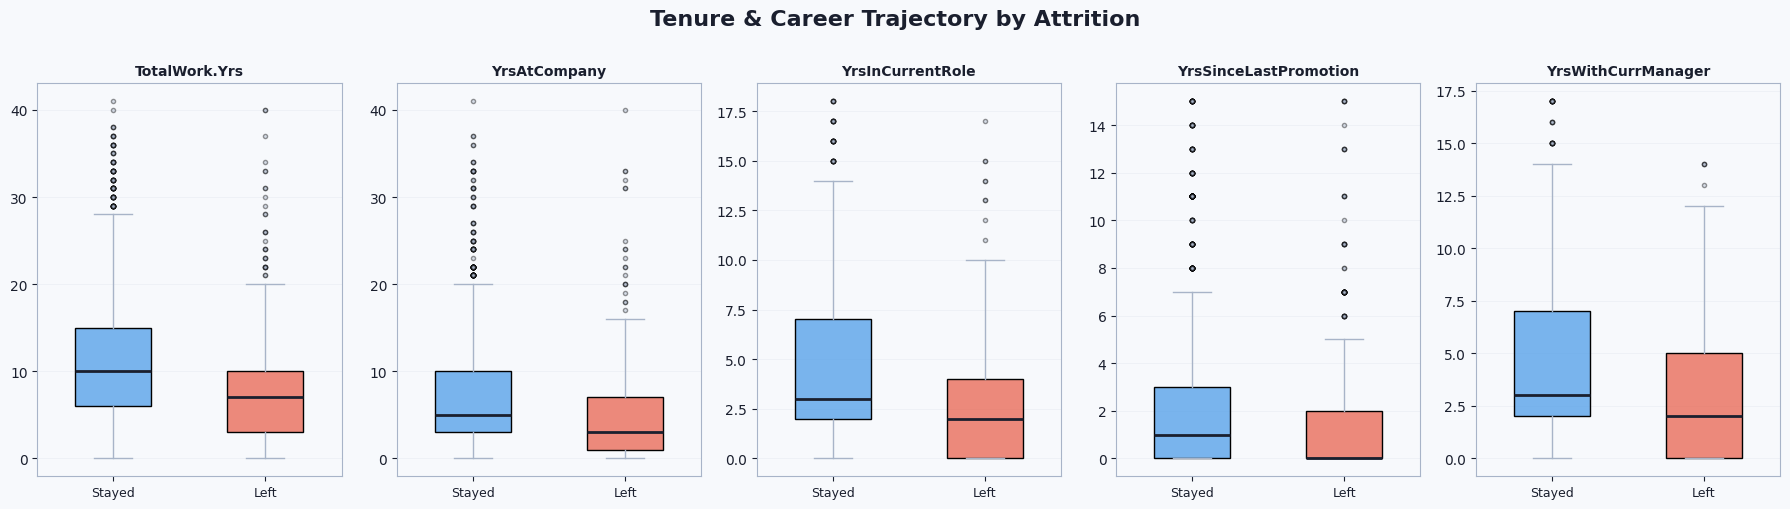

In [29]:
tenure_cols = ["TotalWorkingYears", "YearsAtCompany",
               "YearsInCurrentRole", "YearsSinceLastPromotion",
               "YearsWithCurrManager"]

fig, axes = plt.subplots(1, len(tenure_cols), figsize=(18, 5), facecolor=BG)
fig.suptitle("Tenure & Career Trajectory by Attrition", fontsize=16,
             fontweight="bold", color=DARK, y=1.01)

for ax, col in zip(axes, tenure_cols):
    data = [stayed[col].dropna(), left[col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color=DARK, linewidth=2),
                    whiskerprops=dict(color=MID),
                    capprops=dict(color=MID),
                    flierprops=dict(marker="o", markersize=3,
                                   markerfacecolor=MID, alpha=0.4))
    bp["boxes"][0].set_facecolor(STAY + "BB")
    bp["boxes"][1].set_facecolor(LEAVE + "BB")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Stayed", "Left"], fontsize=9)
    short = col.replace("Years", "Yrs").replace("Working", "Work.")
    ax.set_title(short, fontsize=10)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig_tenure.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


---
## Attrition Rate by Job Role & Level


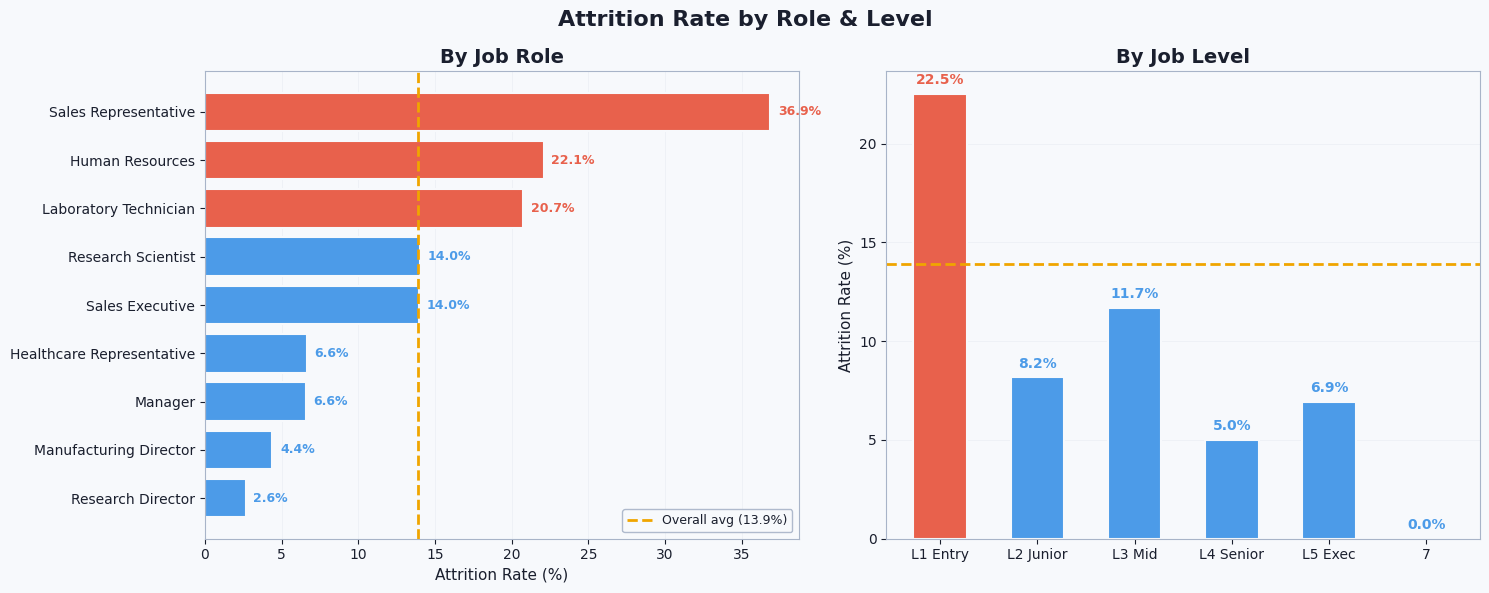

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)
fig.suptitle("Attrition Rate by Role & Level", fontsize=16,
             fontweight="bold", color=DARK)

# By Job Role
role_rate = (df.groupby("JobRole")["Attrition"]
               .mean()
               .sort_values(ascending=True) * 100)
colors_r = [LEAVE if v >= 20 else STAY for v in role_rate]
bars = axes[0].barh(role_rate.index, role_rate.values,
                    color=colors_r, edgecolor=BG, linewidth=1.5)
axes[0].axvline(df["Attrition"].mean() * 100, color=ACCENT,
                linewidth=2, linestyle="--", label=f"Overall avg ({df['Attrition'].mean()*100:.1f}%)")
for bar, val in zip(bars, role_rate.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9,
                 color=LEAVE if val >= 20 else STAY, fontweight="bold")
axes[0].set_xlabel("Attrition Rate (%)")
axes[0].set_title("By Job Role")
axes[0].xaxis.grid(True, alpha=0.4)
axes[0].set_axisbelow(True)
axes[0].legend(fontsize=9)

# By Job Level
level_rate = (df.groupby("JobLevel")["Attrition"]
                .mean()
                .sort_index() * 100)
level_labels = {1: "L1 Entry", 2: "L2 Junior",
                3: "L3 Mid", 4: "L4 Senior", 5: "L5 Exec"}
colors_l = [LEAVE if v >= 20 else STAY for v in level_rate]
xlabels = [level_labels.get(int(l), str(l)) for l in level_rate.index]
axes[1].bar(xlabels,
            level_rate.values, color=colors_l, edgecolor=BG,
            linewidth=1.5, width=0.55)
axes[1].axhline(df["Attrition"].mean() * 100, color=ACCENT,
                linewidth=2, linestyle="--")
for i, val in enumerate(level_rate.values):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center",
                 fontsize=10, fontweight="bold",
                 color=LEAVE if val >= 20 else STAY)
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].set_title("By Job Level")
axes[1].yaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig_role_level.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


---
## Key Takeaways & Insights


In [31]:
rate        = df["Attrition"].mean() * 100
high_role   = df.groupby("JobRole")["Attrition"].mean().idxmax()
high_role_r = df.groupby("JobRole")["Attrition"].mean().max() * 100
ot_left     = df[df["OverTime"]=="Yes"]["Attrition"].mean() * 100
ot_stay     = df[df["OverTime"]=="No"]["Attrition"].mean() * 100
inc_diff    = stayed["MonthlyIncome"].median() - left["MonthlyIncome"].median()
travel_left = df[df["BusinessTravel"]=="Travel_Frequently"]["Attrition"].mean() * 100

print("=" * 60)
print("   KEY INSIGHTS — Employee Attrition Analysis")
print("=" * 60)
print(f"    Overall attrition rate         : {rate:.1f}%")
print(f"    Highest-risk job role           : {high_role} ({high_role_r:.1f}%)")
print(f"    Overtime → attrition rate       : {ot_left:.1f}%  (vs {ot_stay:.1f}% no OT)")
print(f"    Income gap (stayed − left)      : ${inc_diff:,.0f}/month")
print(f"    Frequent travel attrition rate  : {travel_left:.1f}%")
print("=" * 60)
print()
print(" Summary:")
print(f"   • Nearly 1 in 7 employees left — a meaningful business cost.")
print(f"   • Overtime is a strong attrition signal: employees working OT")
print(f"     leave at {ot_left/ot_stay:.1f}× the rate of those who don't.")
print(f"   • Entry-level roles and Sales Representatives show the highest risk.")
print(f"   • Leavers earn ~${inc_diff:,.0f}/month less — compensation matters.")
print(f"   • Frequent business travelers are disproportionately likely to leave.")


   KEY INSIGHTS — Employee Attrition Analysis
    Overall attrition rate         : 13.9%
    Highest-risk job role           : Sales Representative (36.9%)
    Overtime → attrition rate       : 26.3%  (vs 9.5% no OT)
    Income gap (stayed − left)      : $2,174/month
    Frequent travel attrition rate  : 22.3%

 Summary:
   • Nearly 1 in 7 employees left — a meaningful business cost.
   • Overtime is a strong attrition signal: employees working OT
     leave at 2.8× the rate of those who don't.
   • Entry-level roles and Sales Representatives show the highest risk.
   • Leavers earn ~$2,174/month less — compensation matters.
   • Frequent business travelers are disproportionately likely to leave.


---

## Next Steps

| Step | Description |
|------|-------------|
| **Feature Engineering** | Encode categoricals, create interaction features (e.g., OverTime × JobLevel) |
| **Class Imbalance** | Apply SMOTE or class weighting to handle the ~86/14 class split |
| **Modeling** | Train a gradient-boosted classifier (XGBoost / LightGBM) |
| **Explainability** | Use SHAP values to rank the most influential attrition drivers |
| **Business Action** | Translate model outputs into targeted retention interventions |

---
*Analysis produced with Python · pandas · matplotlib · seaborn*
